# I. Project Team Members

| Prepared by | Email | Prepared for |
| :-: | :-: | :-: |
| **Hardefa Rogonondo** | hardefarogonondo@gmail.com | **Kumparan Topic Extractor Engine** |

# II. Notebook Target Definition

_Insert Text Here_

# III. Notebook Setup

## III.A. Import Libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## III.B. Import Data

In [3]:
df = pd.read_csv('../../data/raw/data.csv')

In [4]:
df.head()

,article_id,article_topic,article_content
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har..."
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma..."


# IV. Exploratory Data Analysis

## IV.A. Data Shape Inspection

In [5]:
df.shape

(10000, 3)

## IV.B. Data Information Inspection

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   article_id       10000 non-null  int64 
 1   article_topic    10000 non-null  object
 2   article_content  9964 non-null   object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


## IV.C. Missing Values Inspection

### IV.C.1. Null Values Inspection

In [7]:
df_null = df[df["article_content"].isnull()]
df_null.shape

(36, 3)

In [8]:
df_null.head()

,article_id,article_topic,article_content
197,93210288,Teknologi,NaN
674,93185319,Hiburan,NaN
817,93189481,Hiburan,NaN
972,93184085,Otomotif,NaN
2015,93195291,Hiburan,NaN


### IV.C.2. Whitespaces-Only Values Inspection

In [9]:
whitespace_mask = df["article_content"].str.strip() == ""
df[whitespace_mask].shape

(13, 3)

In [10]:
df[whitespace_mask].head()

,article_id,article_topic,article_content
555,93181418,Hiburan,
1432,93212920,Kesehatan,
1601,93181411,Hiburan,
2342,93190978,Hiburan,
3600,1485824,Hiburan,


### IV.C.3. Null and Whitespaces-Only Values Handling

In [11]:
df.loc[whitespace_mask, "article_content"] = np.nan
df_null = df[df["article_content"].isnull()]
df_null.shape

(49, 3)

In [12]:
df_null.head()

,article_id,article_topic,article_content
197,93210288,Teknologi,NaN
555,93181418,Hiburan,NaN
674,93185319,Hiburan,NaN
817,93189481,Hiburan,NaN
972,93184085,Otomotif,NaN


In [13]:
df_clean = df.dropna(subset=["article_content"])
df_clean.shape

(9951, 3)

In [14]:
df_clean.head()

,article_id,article_topic,article_content
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har..."
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma..."


## IV.D. Duplicated Values Inspection

In [15]:
df_duplicated = df_clean[df_clean.duplicated(subset="article_content", keep=False)]
df_duplicated.shape

(41, 3)

In [16]:
df_duplicated.head()

,article_id,article_topic,article_content
107,1599799,Haji,"KBRN, Madiun (MCH) : Kepala kantor Kementeria..."
497,1599527,Haji,"KBRN, Jember (MCH) : Sebanyak 445 Calon Jemaa..."
791,93181816,Haji,"KBRN, Madiun (MCH) : Kepala kantor Kementeria..."
1006,93188745,Hiburan,#Milad19FPI- Ust.Arifin: Habib Rizieq diterke...
1133,93188517,K-Pop,Acara 'Countdown Asian Games 2018' akan digel...


### IV.D.1. Duplicated Conflicting Topic Inspection

In [19]:
topic_counts = df_clean.groupby("article_content")["article_topic"].nunique()
conflicting_content = topic_counts[topic_counts > 1]
print(f"Number of articles with conflicting labels: {len(conflicting_content)}")

Number of articles with conflicting labels: 6


In [20]:
if len(conflicting_content) > 0:
    conflicting_rows = df_clean[df_clean["article_content"].isin(conflicting_content.index)]
    display(conflicting_rows.sort_values(by="article_content").head(10))
else:
    print("No conflicting labels found.")

,article_id,article_topic,article_content
1006,93188745,Hiburan,#Milad19FPI- Ust.Arifin: Habib Rizieq diterke...
9486,93188743,Politik,#Milad19FPI- Ust.Arifin: Habib Rizieq diterke...
1133,93188517,K-Pop,Acara 'Countdown Asian Games 2018' akan digel...
4195,93188517,Hiburan,Acara 'Countdown Asian Games 2018' akan digel...
6084,93189380,K-Pop,"Bagi para idola k-pop, menjalin kisah asmara ..."
9296,93189380,Hiburan,"Bagi para idola k-pop, menjalin kisah asmara ..."
3585,93206926,Hiburan,Fans EXO mungkin masih teringat akan kejadian...
8862,93206926,K-Pop,Fans EXO mungkin masih teringat akan kejadian...
6036,93188465,K-Pop,Melihat selebriti dalam jarak dekat memang bi...
7096,93188465,Hiburan,Melihat selebriti dalam jarak dekat memang bi...


### IV.D.2. Duplicated Values Handling

In [21]:
conflicting_contents = conflicting_content.index
df_clean = df_clean[~df_clean["article_content"].isin(conflicting_contents)]
df_clean = df_clean.drop_duplicates(subset=["article_content"], keep='first')
df_clean.shape

(9923, 3)

In [22]:
df_clean.head()

,article_id,article_topic,article_content
0,93205794,Internasional,Kepolisian Inggris tengah memburu pelaku yang...
1,93186698,Ekonomi,Seluruh layanan transaksi di jalan tol akan m...
2,93191463,Teknologi,"\nHari ini, Rabu (23/8), ternyata menjadi har..."
3,93219292,Ekonomi,Saat ini Indonesia hanya memiliki cadangan ba...
4,343106,Hiburan,"Hari ini, Selasa (1/8), pedangdut Ridho Rhoma..."


## IV.E. Data Visualization

### IV.E.1. Target Label Proportion

Topic Counts:
 article_topic
Ekonomi          1760
Haji             1484
Hiburan          1433
Sepak Bola       1179
Internasional     739
Lifestyle         568
Teknologi         567
Sports            435
Bojonegoro        260
Kesehatan         192
Sains             174
Otomotif          173
Health            131
Politik            99
Hukum              85
Personal           81
Travel             76
Sejarah            70
Pendidikan         70
Obat-obatan        58
K-Pop              56
Horor              50
KPK                37
Regional           35
MotoGP             35
Bisnis             25
Pilgub Jatim       25
Keuangan           14
Jakarta            12
Name: count, dtype: int64


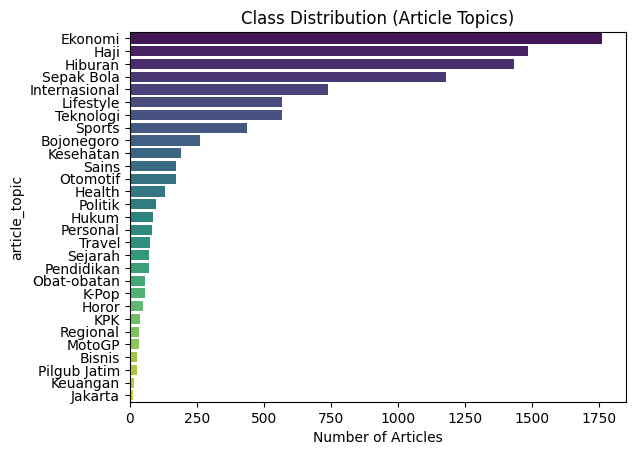

In [24]:
# --- 1. Check Class Balance ---
topic_counts = df_clean['article_topic'].value_counts()
print("Topic Counts:\n", topic_counts)

# Plot (Corrected to fix warning)
sns.barplot(
    x=topic_counts.values, 
    y=topic_counts.index, 
    hue=topic_counts.index,  # Assign the y variable to hue
    legend=False,            # Hide the legend since labels are on the axis
    palette='viridis'
)
plt.title('Class Distribution (Article Topics)')
plt.xlabel('Number of Articles')
plt.show()


Word Count Statistics:
count    9923.000000
mean      353.642850
std       297.172102
min         1.000000
25%       233.000000
50%       303.000000
75%       400.000000
max      9921.000000
Name: word_count, dtype: float64


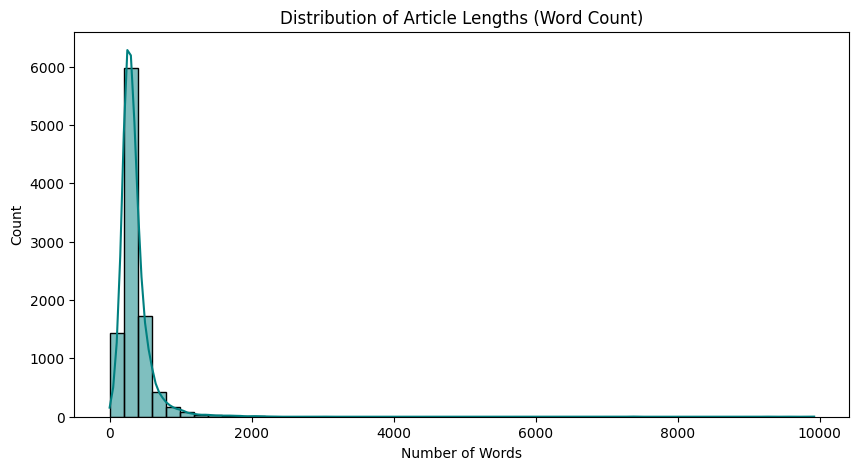

In [25]:
# Calculate word count for every article
df_clean['word_count'] = df_clean['article_content'].apply(lambda x: len(str(x).split()))

# Statistics
print("\nWord Count Statistics:")
print(df_clean['word_count'].describe())

# Plot
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['word_count'], bins=50, kde=True, color='teal')
plt.title('Distribution of Article Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.show()

In [28]:
short_articles = df_clean[df_clean['word_count'] < 20]
print(f"Number of extremely short articles (< 20 words): {len(short_articles)}")
if len(short_articles) > 0:
    print("Example short article content:")
    print(short_articles['article_content'].iloc[0])

Number of extremely short articles (< 20 words): 24
Example short article content:
tes 


# V. Preprocessing

In [27]:
# Remove articles with fewer than 20 words
# This removes "tes", empty placeholders, and broken scraps
df_final = df_clean[df_clean['word_count'] >= 20].copy()

print(f"Rows before filter: {len(df_clean)}")
print(f"Rows after filter: {len(df_final)}")

Rows before filter: 9923
Rows after filter: 9899


## V.C. Imbalance Data Preprocessing

### V.C.1. Random Undersampling

In [ ]:
rus = RandomUnderSampler(random_state=777)
X_undersampled, y_undersampled = rus.fit_resample(X, y)
y_undersampled.value_counts()

### V.C.2. Random Oversampling

In [ ]:
ros = RandomOverSampler(random_state=777)
X_oversampled, y_oversampled = ros.fit_resample(X, y)
y_oversampled.value_counts()

### V.C.3. Synthetic Minority Oversampling Technique (SMOTE)

In [ ]:
categorical_features = X.dtypes == 'object'
categorical_features = categorical_features.tolist()
smote = SMOTENC(categorical_features=categorical_features, random_state=777)
X_smote, y_smote = smote.fit_resample(X, y)
y_smote.value_counts()

## V.D. Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y)

In [ ]:
X_train.shape, X_test.shape

In [ ]:
y_train.shape, y_test.shape

In [ ]:
y_train.value_counts()

In [ ]:
y_test.value_counts()

## V.E. Export Data

In [ ]:
X_train.to_pickle('../../data/processed/X_train.pkl')
X_test.to_pickle('../../data/processed/X_test.pkl')
y_train.to_pickle('../../data/processed/y_train.pkl')
y_test.to_pickle('../../data/processed/y_test.pkl')